In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from sklearn.metrics.pairwise import cosine_similarity
import os

PLOT_SAVE_DIR = './analysis_plots/'
if not os.path.exists(PLOT_SAVE_DIR):
    os.makedirs(PLOT_SAVE_DIR)

def get_raven_data(data):
    raven_columns = ['raven_field.pos0', 'raven_field.pos1', 'raven_field.pos2', 'raven_field.pos3', 'raven_field.pos4', 'raven_field.pos5', 
                     'raven_field.ori0', 'raven_field.ori1', 'raven_field.ori2', 'raven_field.ori3', 'raven_field.ori4', 'raven_field.ori5', 'raven_field.ori6', 'raven_field.ori7', 'raven_field.ori8',
                     'raven_field.ori9', 'raven_field.ori10', 'raven_field.ori11', 'raven_field.ori12', 'raven_field.ori13', 'raven_field.ori14', 'raven_field.ori15', 'raven_field.ori16', 'raven_field.ori17']
    raven_data = data[raven_columns].to_numpy()
    return raven_data

def get_console_data(data):
    console_columns = ['console_pos0', 'console_pos1', 'console_pos2', 'console_pos3', 'console_pos4', 'console_pos5',
                       'console_rot0', 'console_rot1', 'console_rot2', 'console_rot3', 'console_rot4', 'console_rot5']
    console_data = data[console_columns].to_numpy()
    return console_data

def get_trakstar_data(data):
    trakstar_columns = ['trakstar_sensor_1_x', 'trakstar_sensor_1_y', 'trakstar_sensor_1_z', 'trakstar_sensor_3_x', 'trakstar_sensor_3_y', 'trakstar_sensor_3_z',
                        'trakstar_sensor_1_roll', 'trakstar_sensor_1_elevation', 'trakstar_sensor_1_azimuth', 'trakstar_sensor_2_roll', 'trakstar_sensor_2_elevation', 'trakstar_sensor_2_azimuth']
    trakstar_data = data[trakstar_columns].to_numpy()
    return trakstar_data

def get_smartwatch_data(data):
    smartwatch_columns = ['sw_left_x', 'sw_left_y', 'sw_left_z',
                          'sw_right_x', 'sw_right_y', 'sw_right_z']
    smartwatch_data = data[smartwatch_columns].to_numpy()
    return smartwatch_data

def get_pedal_data(data):
    pedal_column = 'console_pedal'
    pedal_data = data[pedal_column].to_numpy()
    return pedal_data

def transform_trackstar_to_console_left(trackstar_pos):
    pos_matrix = np.array([[1,  0,  0], 
                           [0, -1,  0], 
                           [0,  0, -1]])
    psm_pos = pos_matrix @ (trackstar_pos[:, 0:3]*1).T
    trackstar_pos[:, 0:3] = psm_pos.T

    return trackstar_pos

def transform_trackstar_to_console_right(trackstar_pos):
    pos_matrix = np.array([[1,  0,  0], 
                           [0, -1,  0], 
                           [0,  0, -1]])
    psm_pos = pos_matrix @ (trackstar_pos[:, 3:6]*1).T
    trackstar_pos[:, 3:6] = psm_pos.T

    return trackstar_pos

def transform_console_to_raven_left(console_pos):
    
    pos_matrix = np.array([[0, 0, 1], 
                           [1, 0, 0], 
                           [0, 1, 0]])
    
    psm1_pos = pos_matrix @ console_pos[:, 0:3].T
    console_pos[:, 0:3] = psm1_pos.T
    
    return console_pos 

def transform_console_to_raven_right(console_pos):
    pos_matrix = np.array([[0, 0, 1], 
                           [-1, 0, 0], 
                           [0, -1, 0]])
    psm2_pos = pos_matrix @ console_pos[:, 3:6].T
    console_pos[:, 3:6] = psm2_pos.T

    return console_pos 

def transform_trackstar_to_console_rot_1(trackstar_rot_left):
    rot_matrix = np.array([[-1,  0, 0], 
                           [ 0, -1, 0], 
                           [ 0,  0, -1]])
    psm1_rot = rot_matrix @ trackstar_rot_left[:, 0:3].T
    trackstar_rot_left[:, 0:3] = psm1_rot.T

    return trackstar_rot_left

def transform_trackstar_to_console_rot_2(trackstar_rot_right):
    rot_matrix = np.array([[-1,  0, 0], 
                           [ 0, -1, 0], 
                           [ 0,  0, -1]])
    psm2_rot = rot_matrix @ trackstar_rot_right[:, 0:3].T
    trackstar_rot_right[:, 0:3] = psm2_rot.T

    return trackstar_rot_right

def transform_console_to_raven_rot_1(console_rot_left):
    rot_matrix = np.array([[-1,  0,  0], 
                           [ 0,  1,  0], 
                           [ 0,  0,  1]])
    psm1_rot = rot_matrix @ console_rot_left[:, 0:3].T
    console_rot_left[:, 0:3] = psm1_rot.T

    return console_rot_left

def rotation_matrix_to_euler(rot_matrix_flat):
    n_samples = rot_matrix_flat.shape[0]
    euler_angles = np.zeros((n_samples, 3))
    
    for i in range(n_samples):
        # Reshape flat array to 3x3 matrix
        Rmat = rot_matrix_flat[i].reshape(3, 3)
        r = R.from_matrix(Rmat)
        euler_angles[i] = r.as_euler('zyx', degrees=False)  
    return euler_angles

def process_raven_rot(raven_psm_rot):
    processed_rot = raven_psm_rot.copy()
    processed_rot[processed_rot > 4] -= 6.28
    processed_rot[processed_rot < -4] += 6.28
    
    return processed_rot

def process_trakstar_rot(trakstar_psm_rot):
    processed_rot = trakstar_psm_rot.copy()
    processed_rot[processed_rot > 4] -= 6.28
    processed_rot[processed_rot < -4] += 6.28
    
    return processed_rot

def process_smartwatch_pos(smartwatch_data, pedal_data):
    delta_t = 1/30
    g = [0, 0, -9.80665, 0, 0, -9.80665]
    switch_pos = np.zeros((smartwatch_data.shape[0], 6))

    sw_acc = smartwatch_data - g
    sw_pos = sw_acc * delta_t**2
    diff_sw = np.diff(sw_pos, axis=0)
    zero_mask = pedal_data[:-1] == 0
    diff_sw[zero_mask, :] = 0
    switch_pos[1:, :] = np.cumsum(diff_sw, axis=0)
    
    scale_factors = np.array([20000, 10000, 10000, -50000, 20000, 20000])
    switch_pos = switch_pos * scale_factors

    return switch_pos[:, 0:3], switch_pos[:, 3:6]

def process_smartwatch_rot(smartwatch_data, pedal_data):
    
    # Extract left and right smartwatch accelerometer data
    left_acc = smartwatch_data[:, 0:3]   # [ax, ay, az] for left
    right_acc = smartwatch_data[:, 3:6]  # [ax, ay, az] for right
    
    # Initialize output arrays
    left_sw_rot = np.zeros((smartwatch_data.shape[0], 2))   # [roll, pitch]
    right_sw_rot = np.zeros((smartwatch_data.shape[0], 2))  # [roll, pitch]
    
    # Calculate roll and pitch for left smartwatch
    # roll φ = atan2(ay, az)
    left_sw_rot[:, 0] = np.arctan2(left_acc[:, 1], left_acc[:, 2])  # roll
    # pitch θ = atan2(-ax, sqrt(ay² + az²)) - made negative for left smartwatch
    left_sw_rot[:, 1] = -np.arctan2(-left_acc[:, 0], np.sqrt(left_acc[:, 1]**2 + left_acc[:, 2]**2))  # pitch (negative)
    
    # Calculate roll and pitch for right smartwatch
    # roll φ = atan2(ay, az)
    right_sw_rot[:, 0] = np.arctan2(right_acc[:, 1], right_acc[:, 2])  # roll
    # pitch θ = atan2(-ax, sqrt(ay² + az²))
    right_sw_rot[:, 1] = np.arctan2(-right_acc[:, 0], np.sqrt(right_acc[:, 1]**2 + right_acc[:, 2]**2))  # pitch
    
    # Normalize to start at 0 radians by subtracting initial values
    left_sw_rot = left_sw_rot - left_sw_rot[0, :]
    right_sw_rot = right_sw_rot - right_sw_rot[0, :]
    
    # Return in radians (consistent with other rotation data in your code)
    return left_sw_rot, right_sw_rot

def align_console_trackstar_data_pos(new_console, new_trackstar):
    console_pos = new_console[:, [0, 2, 4, 1, 3, 5]]
    trackstar_pos = new_trackstar[:, [0, 1, 2, 3, 4, 5]]
    trackstar_pos = transform_trackstar_to_console_left(trackstar_pos)
    trackstar_pos = transform_trackstar_to_console_right(trackstar_pos)
    console_pos = console_pos - console_pos[0, :]
    trackstar_pos = trackstar_pos - trackstar_pos[0, :]

    return console_pos, trackstar_pos

def align_trackstar_console_raven_rot(new_trackstar, new_console, new_raven):
    console_rot, trackstar_rot = cumulate_trackstar_console_data_rot(new_console, new_trackstar)
    
    trackstar_psm1_rot = trackstar_rot[:, [0, 1, 2]] 
    trackstar_psm2_rot = trackstar_rot[:, [3, 4, 5]] 
    trackstar_psm1_rot = process_trakstar_rot(trackstar_psm1_rot)
    trackstar_psm2_rot = process_trakstar_rot(trackstar_psm2_rot)

    trackstar_psm1_rot = transform_trackstar_to_console_rot_1(trackstar_psm1_rot)
    trackstar_psm2_rot = transform_trackstar_to_console_rot_2(trackstar_psm2_rot)

    console_psm1_rot = console_rot[:, [0, 2, 4]]
    console_psm2_rot = console_rot[:, [1, 3, 5]]

    raven_psm1_rot = rotation_matrix_to_euler(new_raven[:, 6:15])
    raven_psm2_rot = rotation_matrix_to_euler(new_raven[:, 15:24])
    
    raven_psm1_rot = raven_psm1_rot - raven_psm1_rot[0, :]
    raven_psm2_rot = raven_psm2_rot - raven_psm2_rot[0, :]

    raven_psm1_rot = process_raven_rot(raven_psm1_rot)
    raven_psm2_rot = process_raven_rot(raven_psm2_rot)

    console_psm1_rot = transform_console_to_raven_rot_1(console_psm1_rot)
    console_psm2_rot = transform_console_to_raven_rot_1(console_psm2_rot)

    return trackstar_psm1_rot, console_psm1_rot, raven_psm1_rot, trackstar_psm2_rot, console_psm2_rot, raven_psm2_rot

def transform_data(new_console, new_trackstar, new_raven, pedal):
    scale_factors = np.array([2, 1.1, 2.2, 2, 1, 2])
    
    console, trackstar = cumulate_trackstar_console_data(new_console, new_trackstar, pedal)
    raven_pos = (new_raven[:, :] - new_raven[0, :]) * 1e-2
    
    trackstar_pos = transform_console_to_raven_left(trackstar)
    trackstar_pos = transform_console_to_raven_right(trackstar)

    console_pos = transform_console_to_raven_left(console)
    console_pos = transform_console_to_raven_right(console)

    trackstar_pos = trackstar_pos * scale_factors

    return console_pos, trackstar_pos, raven_pos

def cumulate_trackstar_console_data_rot(new_console, new_trackstar):
    console_rot = np.zeros((new_console.shape[0], 6))
    trackstar_rot = np.zeros((new_trackstar.shape[0], 6))

    diff_console = np.diff(new_console[:, 6:], axis=0)
    diff_trackstar = np.diff(np.radians(new_trackstar[:, 6:]), axis=0)

    zero_mask = new_console[:-1, -1] == 0
    diff_console[zero_mask, :] = 0
    console_rot[1:, :] = np.cumsum(diff_console, axis=0)

    diff_trackstar[zero_mask, :] = 0
    trackstar_rot[1:, :] = np.cumsum(diff_trackstar, axis=0)

    return console_rot, trackstar_rot

def cumulate_trackstar_console_data(console_data, trackstar_data, pedal):
    console_pos = np.zeros((console_data.shape[0], 6))
    trackstar_pos = np.zeros((trackstar_data.shape[0], 6))
    
    diff_console = np.diff(console_data, axis=0)
    diff_trackstar = np.diff(trackstar_data, axis=0)

    zero_mask = pedal[:-1] == 0
    diff_console[zero_mask, :] = 0
    console_pos[1:, :] = np.cumsum(diff_console, axis=0)

    diff_trackstar[zero_mask, :] = 0
    trackstar_pos[1:, :] = np.cumsum(diff_trackstar, axis=0)

    return console_pos, trackstar_pos

def plot_xyz_all_left(raven_pos, console_pos, trackstar_pos, left_sw_pos=None):
    labels = ['X', 'Y', 'Z']
    # Create time axis: 30Hz means 1/30 seconds per sample
    time_axis = np.arange(len(raven_pos)) / 30.0
    
    plt.figure(figsize=(12, 8))
    for i in range(3):
        plt.subplot(3, 1, i+1)
        plt.plot(time_axis, raven_pos[:, i], label='Raven', color='#1f77b4', linewidth=2.5)
        plt.plot(time_axis, console_pos[:, i], label='Console', color='#ff7f0e', linewidth=2.5)
        plt.plot(time_axis, trackstar_pos[:, i], label='Trackstar', color='#2ca02c', linewidth=2.5)
        if left_sw_pos is not None:
            sw_time_axis = np.arange(len(left_sw_pos)) / 30.0
            plt.plot(sw_time_axis, left_sw_pos[:, i], label='Smartwatch', color='#d62728', linewidth=2.5)
        if i == 2:  # Only show x-label on the last (bottom) plot
            plt.xlabel('Time (s)', fontsize=16)
        plt.ylabel(f'{labels[i]} (mm)', fontsize=12)
        plt.tick_params(axis='both', which='major', labelsize=12, labelcolor='black')
        # add grid
        plt.grid(True, alpha=0.3)
        if i ==0:  # Only show legend on the last plot
            plt.legend(fontsize=12, ncols=2, loc='lower left')

    plt.tight_layout()
    plt.savefig(f'{PLOT_SAVE_DIR}/position_comparison_left.png', dpi=300)
    plt.show()

def plot_xyz_all_right(raven_pos, console_pos, trackstar_pos, right_sw_pos=None):
    labels = ['X', 'Y', 'Z']
    # Create time axis: 30Hz means 1/30 seconds per sample
    time_axis = np.arange(len(raven_pos)) / 30.0
    
    plt.figure(figsize=(12, 8))
    for i in range(3):
        plt.subplot(3, 1, i+1)
        plt.plot(time_axis, raven_pos[:, i+3], label='Raven', color='#1f77b4', linewidth=2.5)
        plt.plot(time_axis, console_pos[:, i+3], label='Console', color='#ff7f0e', linewidth=2.5)
        plt.plot(time_axis, trackstar_pos[:, i+3], label='Trakstar', color='#2ca02c', linewidth=2.5)
        if right_sw_pos is not None:
            sw_time_axis = np.arange(len(right_sw_pos)) / 30.0
            plt.plot(sw_time_axis, right_sw_pos[:, i], label='Smartwatch', color='#d62728', linewidth=2.5)
        if i == 2:  # Only show x-label on the last (bottom) plot
            plt.xlabel('Time (s)', fontsize=12)
        plt.ylabel(f'{labels[i]} (mm)', fontsize=12)
        plt.tick_params(axis='both', which='major', labelsize=10, labelcolor='black')
        legend = plt.legend(fontsize=10)
        # Make legend text bold

        # Make tick labels bold

    plt.tight_layout()
    plt.savefig(f'{PLOT_SAVE_DIR}/position_comparison_right.png', dpi=300)
    plt.show()

def plot_rotation_comparison_three(trackstar_rot, console_rot, raven_rot, smartwatch_rot=None):
    """Plot trackstar, console, raven and smartwatch rotation data comparison"""
    labels = ['Roll', 'Pitch', 'Yaw']
    # Create time axis: 30Hz means 1/30 seconds per sample
    time_axis = np.arange(len(raven_rot)) / 30.0
    
    plt.figure(figsize=(12, 8))
    for i in range(3):
        plt.subplot(3, 1, i+1)
        plt.plot(time_axis, raven_rot[:, i], label='Raven', color='#1f77b4', linewidth=2.5)
        plt.plot(time_axis, console_rot[:, i], label='Console', color='#ff7f0e', linewidth=2.5)
        plt.plot(time_axis, trackstar_rot[:, i], label='Trakstar', color='#2ca02c', linewidth=2.5)
        # Add smartwatch data for roll and pitch only (smartwatch doesn't have yaw)
        if smartwatch_rot is not None and i < 2:  # Only for roll (i=0) and pitch (i=1)
            sw_time_axis = np.arange(len(smartwatch_rot)) / 30.0
            plt.plot(sw_time_axis, smartwatch_rot[:, i], label='Smartwatch', color='#d62728', linewidth=2.5)
        if i == 2:  # Only show x-label on the last (bottom) plot
            plt.xlabel('Time (s)', fontsize=16)
        plt.ylabel(f'{labels[i]} (rad)', fontsize=12)
        plt.tick_params(axis='both', which='major', labelsize=12, labelcolor='black')
        plt.grid(True, alpha=0.3)
        if i ==0:  # Only show legend on the last plot
            plt.legend(fontsize=12, ncols=2)
        # # Make legend text bold
        # for text in legend.get_texts():
        #     text.set_fontweight('bold')
        # # Make tick labels bold
        # ax = plt.gca()
        # for label in ax.get_xticklabels():
        #     label.set_fontweight('bold')
        # for label in ax.get_yticklabels():
        #     label.set_fontweight('bold')
    plt.tight_layout()
    plt.savefig(f'{PLOT_SAVE_DIR}/rotation_comparison_three.png', dpi=300)
    plt.show()

def plot_smartwatch_rotation(left_sw_rot, right_sw_rot):
    """Plot smartwatch rotation data (roll and pitch) for both left and right"""
    labels = ['Roll', 'Pitch']
    # Create time axis: 30Hz means 1/30 seconds per sample
    time_axis = np.arange(len(left_sw_rot)) / 30.0
    
    # Plot left smartwatch rotation
    plt.figure(figsize=(12, 8))
    plt.suptitle('Smartwatch Rotation Data', fontsize=16)
    
    for i in range(2):  # Roll and Pitch
        # Left smartwatch
        plt.subplot(2, 2, i+1)
        plt.plot(time_axis, left_sw_rot[:, i], label=f'Left {labels[i]}', 
                color='#1f77b4', linewidth=2.5)
        plt.ylabel(f'{labels[i]} (radians)', fontsize=12)
        plt.title(f'Left Smartwatch {labels[i]}', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=10)
        if i == 1:  # Only show x-label on bottom plots
            plt.xlabel('Time (s)', fontsize=12)
        
        # Right smartwatch
        plt.subplot(2, 2, i+3)
        plt.plot(time_axis, right_sw_rot[:, i], label=f'Right {labels[i]}', 
                color='#ff7f0e', linewidth=2.5)
        plt.ylabel(f'{labels[i]} (radians)', fontsize=12)
        plt.title(f'Right Smartwatch {labels[i]}', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=10)
        if i == 1:  # Only show x-label on bottom plots
            plt.xlabel('Time (s)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'{PLOT_SAVE_DIR}/smartwatch_rotation.png', dpi=300)
    plt.show()

def calculate_cosine_similarity_pos(data1, data2):
    """
    Calculate Cosine Similarity between two datasets for each axis
    Args:
        data1: First dataset (N x 6 array)
        data2: Second dataset (N x 6 array)
    Returns:
        cosine_left_xyz: Cosine similarity for left arm X, Y, Z
        cosine_right_xyz: Cosine similarity for right arm X, Y, Z
        cosine_per_dim: Cosine similarity for each dimension separately
        cosine_overall: Overall cosine similarity considering all dimensions
    """
    # Ensure both datasets have the same shape
    min_length = min(data1.shape[0], data2.shape[0])
    data1 = data1[:min_length, :6]
    data2 = data2[:min_length, :6]
    
    # Calculate cosine similarity for each dimension
    cosine_per_dim = np.zeros(6)
    for i in range(6):
        # Reshape for sklearn's cosine_similarity function
        vec1 = data1[:, i].reshape(1, -1)
        vec2 = data2[:, i].reshape(1, -1)
        cosine_per_dim[i] = cosine_similarity(vec1, vec2)[0, 0]
    
    # Cosine similarity for left arm X, Y, Z
    cosine_left_xyz = cosine_per_dim[:3]  # [left_x, left_y, left_z]
    
    # Cosine similarity for right arm X, Y, Z
    cosine_right_xyz = cosine_per_dim[3:]  # [right_x, right_y, right_z]
    
    # Overall cosine similarity considering all dimensions as one vector
    cosine_overall = cosine_similarity(data1.reshape(1, -1), data2.reshape(1, -1))[0, 0]
    
    return cosine_left_xyz, cosine_right_xyz, cosine_per_dim, cosine_overall

def print_cosine_similarity_results(name1, name2, cosine_left_xyz, cosine_right_xyz, cosine_per_dim, cosine_overall):
    """Print cosine similarity results in a formatted way with separate X, Y, Z values"""
    print(f"\n=== Cosine Similarity Analysis: {name1} vs {name2} ===")
    print(f"Overall Cosine Similarity: {cosine_overall:.6f}")
    
    print("\nLeft Arm Cosine Similarity by axis:")
    print(f"  X: {cosine_left_xyz[0]:.6f}")
    print(f"  Y: {cosine_left_xyz[1]:.6f}")
    print(f"  Z: {cosine_left_xyz[2]:.6f}")
    print(f"  Average: {np.mean(cosine_left_xyz):.6f}")
    
    print("\nRight Arm Cosine Similarity by axis:")
    print(f"  X: {cosine_right_xyz[0]:.6f}")
    print(f"  Y: {cosine_right_xyz[1]:.6f}")
    print(f"  Z: {cosine_right_xyz[2]:.6f}")
    print(f"  Average: {np.mean(cosine_right_xyz):.6f}")
    
    print(f"\nAverage Cosine Similarity (per dimension): {np.mean(cosine_per_dim):.6f}")

def calculate_nrmse_pos(data1, data2, normalization_method='range'):
    """
    Calculate Normalized Root Mean Square Error between two datasets
    Args:
        data1: First dataset (N x 6 array) - predicted values
        data2: Second dataset (N x 6 array) - reference/true values
        normalization_method: Method for normalization ('range', 'mean', 'std')
    Returns:
        nrmse_total: Overall normalized RMSE across all dimensions (as percentage)
        nrmse_left_xyz: Normalized RMSE for left arm X, Y, Z separately
        nrmse_right_xyz: Normalized RMSE for right arm X, Y, Z separately
        nrmse_per_dim: Normalized RMSE for each dimension separately
    """
    # Ensure both datasets have the same shape
    min_length = min(data1.shape[0], data2.shape[0])
    data1 = data1[:min_length, :6]
    data2 = data2[:min_length, :6]
    
    # Calculate squared differences
    squared_diff = (data1 - data2) ** 2
    
    # Calculate RMSE first
    rmse_total = np.sqrt(np.mean(squared_diff))
    rmse_per_dim = np.sqrt(np.mean(squared_diff, axis=0))
    
    # Calculate normalization factors based on reference data (data2)
    if normalization_method == 'range':
        # Normalize by range (max - min) for each dimension
        normalization_factors = np.ptp(data2, axis=0)  # ptp = peak-to-peak (max - min)
        overall_normalization = np.ptp(data2)  # Overall range across all values
    elif normalization_method == 'mean':
        # Normalize by mean for each dimension
        normalization_factors = np.abs(np.mean(data2, axis=0))
        overall_normalization = np.abs(np.mean(data2))
    elif normalization_method == 'std':
        # Normalize by standard deviation for each dimension
        normalization_factors = np.std(data2, axis=0)
        overall_normalization = np.std(data2)
    else:
        raise ValueError("normalization_method must be 'range', 'mean', or 'std'")
    
    # Avoid division by zero
    normalization_factors[normalization_factors == 0] = 1
    if overall_normalization == 0:
        overall_normalization = 1
    
    # Calculate normalized RMSE (as percentage)
    nrmse_total = (rmse_total / overall_normalization) * 100
    nrmse_per_dim = (rmse_per_dim / normalization_factors) * 100
    
    # NRMSE for left arm X, Y, Z separately
    nrmse_left_xyz = nrmse_per_dim[:3]  # [left_x, left_y, left_z]
    
    # NRMSE for right arm X, Y, Z separately
    nrmse_right_xyz = nrmse_per_dim[3:]  # [right_x, right_y, right_z]
    
    return nrmse_total, nrmse_left_xyz, nrmse_right_xyz, nrmse_per_dim

def print_nrmse_results(name1, name2, nrmse_total, nrmse_left_xyz, nrmse_right_xyz, nrmse_per_dim):
    """Print Normalized RMSE results in a formatted way with separate X, Y, Z values (as percentages)"""
    print(f"\n=== Normalized RMSE Analysis: {name1} vs {name2} ===")
    print(f"Overall NRMSE: {nrmse_total:.2f}%")
    print("\nLeft Arm NRMSE by axis:")
    print(f"  X: {nrmse_left_xyz[0]:.2f}%")
    print(f"  Y: {nrmse_left_xyz[1]:.2f}%")
    print(f"  Z: {nrmse_left_xyz[2]:.2f}%")
    print(f"  Combined: {np.sqrt(np.mean(nrmse_left_xyz**2)):.2f}%")
    
    print("\nRight Arm NRMSE by axis:")
    print(f"  X: {nrmse_right_xyz[0]:.2f}%")
    print(f"  Y: {nrmse_right_xyz[1]:.2f}%")
    print(f"  Z: {nrmse_right_xyz[2]:.2f}%")
    print(f"  Combined: {np.sqrt(np.mean(nrmse_right_xyz**2)):.2f}%")

def calculate_cosine_similarity_rot(rot_data1, rot_data2):
    """
    Calculate Cosine Similarity between two rotation datasets
    Args:
        rot_data1: First rotation dataset (N x 3 array) - predicted rotation values
        rot_data2: Second rotation dataset (N x 3 array) - reference rotation values
    Returns:
        cosine_left_xyz: Cosine similarity for left arm Roll, Pitch, Yaw
        cosine_right_xyz: Cosine similarity for right arm Roll, Pitch, Yaw (same as left for single PSM)
        cosine_per_dim: Cosine similarity for each dimension separately
        cosine_overall: Overall cosine similarity considering all dimensions
    """
    # Ensure both datasets have the same shape
    min_length = min(rot_data1.shape[0], rot_data2.shape[0])
    rot_data1 = rot_data1[:min_length, :3]
    rot_data2 = rot_data2[:min_length, :3]
    
    # Calculate cosine similarity for each rotation axis
    cosine_per_dim = np.zeros(3)
    for i in range(3):
        # Reshape for sklearn's cosine_similarity function
        vec1 = rot_data1[:, i].reshape(1, -1)
        vec2 = rot_data2[:, i].reshape(1, -1)
        cosine_per_dim[i] = cosine_similarity(vec1, vec2)[0, 0]
    
    # For rotation, we treat this as a single PSM, so left and right are the same
    cosine_left_xyz = cosine_per_dim  # [roll, pitch, yaw]
    cosine_right_xyz = cosine_per_dim  # Same values for consistency with position format
    
    # Overall cosine similarity considering all rotation dimensions as one vector
    cosine_overall = cosine_similarity(rot_data1.reshape(1, -1), rot_data2.reshape(1, -1))[0, 0]
    
    return cosine_left_xyz, cosine_right_xyz, cosine_per_dim, cosine_overall

def print_cosine_similarity_rot_results(name1, name2, cosine_left_xyz, cosine_right_xyz, cosine_per_dim, cosine_overall):
    """Print rotation cosine similarity results in the same format as position results"""
    print(f"\n=== Cosine Similarity Analysis: {name1} vs {name2} ===")
    print(f"Overall Cosine Similarity: {cosine_overall:.6f}")
    
    print("\nLeft Arm Cosine Similarity by axis:")
    print(f"  Roll: {cosine_left_xyz[0]:.6f}")
    print(f"  Pitch: {cosine_left_xyz[1]:.6f}")
    print(f"  Yaw: {cosine_left_xyz[2]:.6f}")
    print(f"  Average: {np.mean(cosine_left_xyz):.6f}")
    
    print("\nRight Arm Cosine Similarity by axis:")
    print(f"  Roll: {cosine_right_xyz[0]:.6f}")
    print(f"  Pitch: {cosine_right_xyz[1]:.6f}")
    print(f"  Yaw: {cosine_right_xyz[2]:.6f}")
    print(f"  Average: {np.mean(cosine_right_xyz):.6f}")
    
    print(f"\nAverage Cosine Similarity (per dimension): {np.mean(cosine_per_dim):.6f}")

def calculate_nrmse_rot(rot_data1, rot_data2, normalization_method='range'):
    """
    Calculate Normalized Root Mean Square Error between two rotation datasets
    Args:
        rot_data1: First rotation dataset (N x 3 array) - predicted rotation values
        rot_data2: Second rotation dataset (N x 3 array) - reference/true rotation values
        normalization_method: Method for normalization ('range', 'mean', 'std')
    Returns:
        nrmse_total: Overall normalized RMSE across all rotation dimensions (as percentage)
        nrmse_left_xyz: Normalized RMSE for left arm Roll, Pitch, Yaw
        nrmse_right_xyz: Normalized RMSE for right arm Roll, Pitch, Yaw (same as left for single PSM)
        nrmse_per_dim: Normalized RMSE for each dimension separately
    """
    # Ensure both datasets have the same shape
    min_length = min(rot_data1.shape[0], rot_data2.shape[0])
    rot_data1 = rot_data1[:min_length, :3]
    rot_data2 = rot_data2[:min_length, :3]
    
    # Calculate squared differences
    squared_diff = (rot_data1 - rot_data2) ** 2
    
    # Calculate RMSE first
    rmse_total = np.sqrt(np.mean(squared_diff))
    rmse_per_dim = np.sqrt(np.mean(squared_diff, axis=0))
    
    # Calculate normalization factors based on reference data (rot_data2)
    if normalization_method == 'range':
        # Normalize by range (max - min) for each dimension
        normalization_factors = np.ptp(rot_data2, axis=0)  # ptp = peak-to-peak (max - min)
        overall_normalization = np.ptp(rot_data2)  # Overall range across all values
    elif normalization_method == 'mean':
        # Normalize by mean for each dimension
        normalization_factors = np.abs(np.mean(rot_data2, axis=0))
        overall_normalization = np.abs(np.mean(rot_data2))
    elif normalization_method == 'std':
        # Normalize by standard deviation for each dimension
        normalization_factors = np.std(rot_data2, axis=0)
        overall_normalization = np.std(rot_data2)
    else:
        raise ValueError("normalization_method must be 'range', 'mean', or 'std'")
    
    # Avoid division by zero
    normalization_factors[normalization_factors == 0] = 1
    if overall_normalization == 0:
        overall_normalization = 1
    
    # Calculate normalized RMSE (as percentage)
    nrmse_total = (rmse_total / overall_normalization) * 100
    nrmse_per_dim = (rmse_per_dim / normalization_factors) * 100
    
    # For rotation, we treat this as a single PSM, so left and right are the same
    nrmse_left_xyz = nrmse_per_dim  # [roll, pitch, yaw]
    nrmse_right_xyz = nrmse_per_dim  # Same values for consistency with position format
    
    return nrmse_total, nrmse_left_xyz, nrmse_right_xyz, nrmse_per_dim

def print_nrmse_rot_results(name1, name2, nrmse_total, nrmse_left_xyz, nrmse_right_xyz, nrmse_per_dim):
    """Print Normalized RMSE results for rotation data in the same format as position results (as percentages)"""
    print(f"\n=== Normalized RMSE Analysis: {name1} vs {name2} ===")
    print(f"Overall NRMSE: {nrmse_total:.2f}%")
    print("\nLeft Arm NRMSE by axis:")
    print(f"  Roll: {nrmse_left_xyz[0]:.2f}%")
    print(f"  Pitch: {nrmse_left_xyz[1]:.2f}%")
    print(f"  Yaw: {nrmse_left_xyz[2]:.2f}%")
    print(f"  Combined: {np.sqrt(np.mean(nrmse_left_xyz**2)):.2f}%")
    
    print("\nRight Arm NRMSE by axis:")
    print(f"  Roll: {nrmse_right_xyz[0]:.2f}%")
    print(f"  Pitch: {nrmse_right_xyz[1]:.2f}%")
    print(f"  Yaw: {nrmse_right_xyz[2]:.2f}%")
    print(f"  Combined: {np.sqrt(np.mean(nrmse_right_xyz**2)):.2f}%")


In [2]:
trial = 2

file_path = f'/standard/UVA-DSA/MIDAS/Organized/final_data/t{trial}/synched_data/final_annotation_t{trial}.csv'
print("trial", trial)
data = pd.read_csv(file_path)

raven_data = get_raven_data(data)[2000:-1200]
console_data = get_console_data(data)[2000:-1200]
trakstar_data = get_trakstar_data(data)[2000:-1200]
smartwatch_data = get_smartwatch_data(data)[2000:-1200]
pedal_data = get_pedal_data(data)[2000:-1200]

left_sw_pos, right_sw_pos = process_smartwatch_pos(smartwatch_data, pedal_data)
left_sw_rot, right_sw_rot = process_smartwatch_rot(smartwatch_data, pedal_data)

# Plot smartwatch rotation data
# plot_smartwatch_rotation(left_sw_rot, right_sw_rot)
trackstar_psm1_rot, console_psm1_rot, raven_psm1_rot, trackstar_psm2_rot, console_psm2_rot, raven_psm2_rot = align_trackstar_console_raven_rot(trakstar_data, console_data, raven_data)


# nrmse_total_tr, nrmse_left_xyz_tr, nrmse_right_xyz_tr, nrmse_per_dim_tr = calculate_nrmse_pos(new_trackstar_pos, new_raven_pos)
# print_nrmse_results("Trackstar", "Raven", nrmse_total_tr, nrmse_left_xyz_tr, nrmse_right_xyz_tr, nrmse_per_dim_tr)

# # Calculate NRMSE between console and raven positions
# nrmse_total_cr, nrmse_left_xyz_cr, nrmse_right_xyz_cr, nrmse_per_dim_cr = calculate_nrmse_pos(new_console_pos, new_raven_pos)
# print_nrmse_results("Console", "Raven", nrmse_total_cr, nrmse_left_xyz_cr, nrmse_right_xyz_cr, nrmse_per_dim_cr)

# cosine_left_xyz_tr, cosine_right_xyz_tr, cosine_per_dim_tr, cosine_overall_tr = calculate_cosine_similarity_pos(new_trackstar_pos, new_raven_pos)
# print_cosine_similarity_results("Trackstar", "Raven", cosine_left_xyz_tr, cosine_right_xyz_tr, cosine_per_dim_tr, cosine_overall_tr)

# cosine_left_xyz_cr, cosine_right_xyz_cr, cosine_per_dim_cr, cosine_overall_cr = calculate_cosine_similarity_pos(new_console_pos, new_raven_pos)
# print_cosine_similarity_results("Console", "Raven", cosine_left_xyz_cr, cosine_right_xyz_cr, cosine_per_dim_cr, cosine_overall_cr)

# # Calculate rotation cosine similarity for PSM1 (left arm)
# cosine_left_xyz_tr_psm1, cosine_right_xyz_tr_psm1, cosine_per_dim_tr_psm1, cosine_overall_tr_psm1 = calculate_cosine_similarity_rot(trackstar_psm1_rot, raven_psm1_rot)
# print_cosine_similarity_rot_results("Trackstar PSM1", "Raven PSM1", cosine_left_xyz_tr_psm1, cosine_right_xyz_tr_psm1, cosine_per_dim_tr_psm1, cosine_overall_tr_psm1)

# cosine_left_xyz_cr_psm1, cosine_right_xyz_cr_psm1, cosine_per_dim_cr_psm1, cosine_overall_cr_psm1 = calculate_cosine_similarity_rot(console_psm1_rot, raven_psm1_rot)
# print_cosine_similarity_rot_results("Console PSM1", "Raven PSM1", cosine_left_xyz_cr_psm1, cosine_right_xyz_cr_psm1, cosine_per_dim_cr_psm1, cosine_overall_cr_psm1)

# # Calculate rotation cosine similarity for PSM2 (right arm)
# cosine_left_xyz_tr_psm2, cosine_right_xyz_tr_psm2, cosine_per_dim_tr_psm2, cosine_overall_tr_psm2 = calculate_cosine_similarity_rot(trackstar_psm2_rot, raven_psm2_rot)
# print_cosine_similarity_rot_results("Trackstar PSM2", "Raven PSM2", cosine_left_xyz_tr_psm2, cosine_right_xyz_tr_psm2, cosine_per_dim_tr_psm2, cosine_overall_tr_psm2)

# cosine_left_xyz_cr_psm2, cosine_right_xyz_cr_psm2, cosine_per_dim_cr_psm2, cosine_overall_cr_psm2 = calculate_cosine_similarity_rot(console_psm2_rot, raven_psm2_rot)
# print_cosine_similarity_rot_results("Console PSM2", "Raven PSM2", cosine_left_xyz_cr_psm2, cosine_right_xyz_cr_psm2, cosine_per_dim_cr_psm2, cosine_overall_cr_psm2)

# # Calculate rotation NRMSE for PSM1 (left arm)
# nrmse_total_tr_psm1, nrmse_left_xyz_tr_psm1, nrmse_right_xyz_tr_psm1, nrmse_per_dim_tr_psm1 = calculate_nrmse_rot(trackstar_psm1_rot, raven_psm1_rot)
# print_nrmse_rot_results("Trackstar PSM1", "Raven PSM1", nrmse_total_tr_psm1, nrmse_left_xyz_tr_psm1, nrmse_right_xyz_tr_psm1, nrmse_per_dim_tr_psm1)

# nrmse_total_cr_psm1, nrmse_left_xyz_cr_psm1, nrmse_right_xyz_cr_psm1, nrmse_per_dim_cr_psm1 = calculate_nrmse_rot(console_psm1_rot, raven_psm1_rot)
# print_nrmse_rot_results("Console PSM1", "Raven PSM1", nrmse_total_cr_psm1, nrmse_left_xyz_cr_psm1, nrmse_right_xyz_cr_psm1, nrmse_per_dim_cr_psm1)

# # Calculate rotation NRMSE for PSM2 (right arm)
# nrmse_total_tr_psm2, nrmse_left_xyz_tr_psm2, nrmse_right_xyz_tr_psm2, nrmse_per_dim_tr_psm2 = calculate_nrmse_rot(trackstar_psm2_rot, raven_psm2_rot)
# print_nrmse_rot_results("Trackstar PSM2", "Raven PSM2", nrmse_total_tr_psm2, nrmse_left_xyz_tr_psm2, nrmse_right_xyz_tr_psm2, nrmse_per_dim_tr_psm2)

# nrmse_total_cr_psm2, nrmse_left_xyz_cr_psm2, nrmse_right_xyz_cr_psm2, nrmse_per_dim_cr_psm2 = calculate_nrmse_rot(console_psm2_rot, raven_psm2_rot)
# print_nrmse_rot_results("Console PSM2", "Raven PSM2", nrmse_total_cr_psm2, nrmse_left_xyz_cr_psm2, nrmse_right_xyz_cr_psm2, nrmse_per_dim_cr_psm2)

trial 2


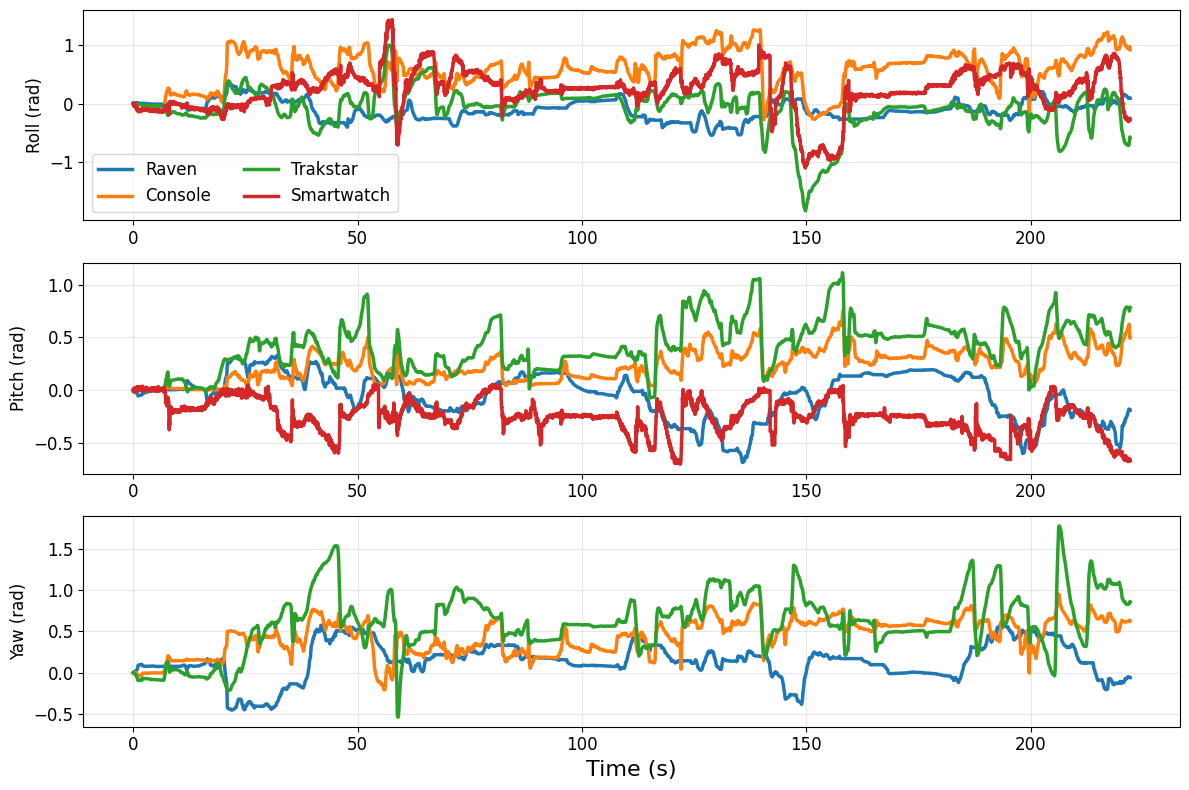

In [3]:
plot_rotation_comparison_three(trackstar_psm1_rot, console_psm1_rot, raven_psm1_rot, left_sw_rot)
# plot_rotation_comparison_three(trackstar_psm2_rot, console_psm2_rot, raven_psm2_rot, right_sw_rot)



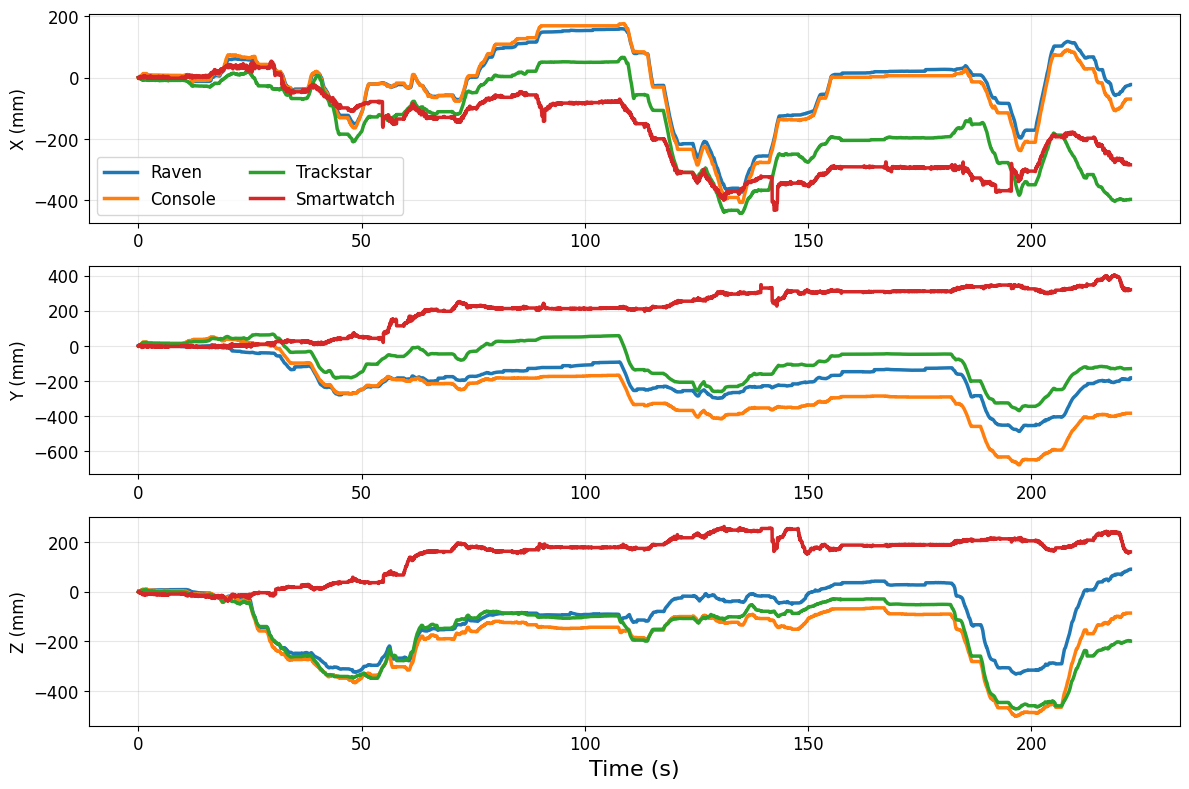

In [4]:
console_pos, trackstar_pos = align_console_trackstar_data_pos(console_data, trakstar_data)
new_console_pos, new_trackstar_pos, new_raven_pos = transform_data(console_pos, trackstar_pos, raven_data, pedal_data)

plot_xyz_all_left(new_raven_pos, new_console_pos, new_trackstar_pos, left_sw_pos)
# plot_xyz_all_right(new_raven_pos, new_console_pos, new_trackstar_pos, right_sw_pos)

(<Figure size 1200x400 with 6 Axes>,
 ([<Axes: ylabel='X (mm)'>,
   <Axes: ylabel='Y (mm)'>,
   <Axes: xlabel='Time (s)', ylabel='Z (mm)'>],
  [<Axes: ylabel='Roll (rad)'>,
   <Axes: ylabel='Pitch (rad)'>,
   <Axes: xlabel='Time (s)', ylabel='Yaw (rad)'>]))

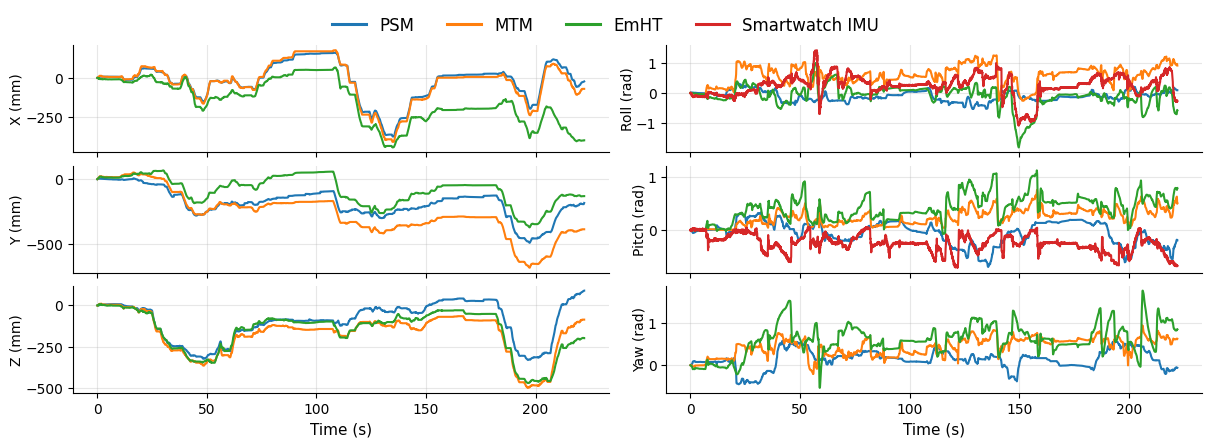

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_pos_rot_side_by_side(
    raven_pos, console_pos, trackstar_pos, 
    raven_rot, console_rot, trackstar_rot,
    left_sw_pos=None, smartwatch_rot=None,
    fps=30.0,
    out_path="pos_rot_side_by_side.png",
    textwidth_in=6.8,     # ~\textwidth for most venues
    height_in=8.2,      # Chosen for readability (3 stacked rows)
    left_label="Position (mm)",
    right_label="Rotation (rad)"
):
    """
    Create a 3x2 grid: left column = X/Y/Z position comparisons,
    right column = Roll/Pitch/Yaw rotation comparisons.
    
    Parameters
    ----------
    raven_pos, console_pos, trackstar_pos : (T,3) arrays
    raven_rot, console_rot, trackstar_rot : (T,3) arrays
    left_sw_pos : (T_sw,3) array or None  (optional smartwatch position)
    smartwatch_rot : (T_sw,2) array or None  (optional smartwatch rotation: roll, pitch; no yaw)
    fps : float
        Sampling rate used to build time axes.
    out_path : str or Path
        Filepath to save the figure (PNG). Saved at 300 dpi, tight bbox.
    textwidth_in : float
        Figure width in inches for a one-column figure. Height is computed for readability.
    left_label, right_label : str
        Y-axis super-labels for each column.
    """
    # Colors to match your existing plots
    COL_RAVEN   = '#1f77b4'
    COL_CONSOLE = '#ff7f0e'
    COL_TSTAR   = '#2ca02c'
    COL_SW      = '#d62728'

    # Time axes
    T_pos = raven_pos.shape[0]
    T_rot = raven_rot.shape[0]
    t_pos = np.arange(T_pos) / fps
    t_rot = np.arange(T_rot) / fps

    if left_sw_pos is not None:
        t_sw_pos = np.arange(left_sw_pos.shape[0]) / fps
    if smartwatch_rot is not None:
        t_sw_rot = np.arange(smartwatch_rot.shape[0]) / fps

    # Labels
    pos_labels = ['X (mm)', 'Y (mm)', 'Z (mm)']
    rot_labels = ['Roll (rad)', 'Pitch (rad)', 'Yaw (rad)']

    # legend mapping
    label_map = {
        'Raven': "PSM",
        'Console': "MTM",
        'Trakstar': "EmHT",
        'Smartwatch': "Smartwatch IMU"
    }

    # Layout: keep width at textwidth; choose height for 3 stacked rows readable in print
    # Aim ~1.15 aspect height per column stack
    fig = plt.figure(figsize=(textwidth_in, height_in), constrained_layout=True)
    gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[1, 1], wspace=0.02, hspace=0.02)

    axes_left = [fig.add_subplot(gs[i, 0]) for i in range(3)]
    axes_right = [fig.add_subplot(gs[i, 1]) for i in range(3)]

    # ----- Left column: XYZ positions -----
    for i, ax in enumerate(axes_left):
        ax.plot(t_pos, raven_pos[:, i],   label='Raven',    color=COL_RAVEN,   linewidth=1.5)
        ax.plot(t_pos, console_pos[:, i], label='Console',  color=COL_CONSOLE, linewidth=1.5)
        ax.plot(t_pos, trackstar_pos[:, i], label='Trakstar', color=COL_TSTAR, linewidth=1.5)
        if left_sw_pos is not None:
            ax.plot(t_sw_pos, left_sw_pos[:, i], label='Smartwatch', color=COL_SW, linewidth=1.5)

        ax.set_ylabel(f'{pos_labels[i]}', fontsize=10, labelpad=1)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=10)
        if i < 2:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel('Time (s)', fontsize=11)

    # ----- Right column: R/P/Y rotations -----
    for i, ax in enumerate(axes_right):
        ax.plot(t_rot, raven_rot[:, i],   label='Raven',    color=COL_RAVEN,   linewidth=1.5)
        ax.plot(t_rot, console_rot[:, i], label='Console',  color=COL_CONSOLE, linewidth=1.5)
        ax.plot(t_rot, trackstar_rot[:, i], label='Trakstar', color=COL_TSTAR, linewidth=1.5)

        # Smartwatch: only roll (0) & pitch (1)
        if smartwatch_rot is not None and i < 2:
            ax.plot(t_sw_rot, smartwatch_rot[:, i], label='Smartwatch', color=COL_SW, linewidth=1.5)

        ax.set_ylabel(f'{rot_labels[i]}', fontsize=10, labelpad=0)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=10)
        if i < 2:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel('Time (s)', fontsize=11)

    # Column headers

    # Column super y-labels
    # (Use fig.text so they sit centered along each column)
    # fig.text(0.02, 0.5, left_label, va='center', rotation='vertical', fontsize=12)
    # fig.text(0.52, 0.5, right_label, va='center', rotation='vertical', fontsize=12)

    # Build a single, clean global legend
    # Determine which labels are present
    handles, labels = [], []
    for ax in (axes_left[0], axes_right[0]):
        h, l = ax.get_legend_handles_labels()
        handles += h; labels += l
    # Deduplicate while preserving order
    seen, handles_dedup, labels_dedup = set(), [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            handles_dedup.append(h)
            labels_dedup.append(l)
    legend = fig.legend(handles_dedup, labels_dedup, loc='upper center', ncol=4, fontsize=12,
               frameon=False, bbox_to_anchor=(0.5, 1.1), borderaxespad=0.5)
    for line in legend.get_lines():
        line.set_linewidth(2.2)

    for ax in axes_left + axes_right:
        ax.yaxis.labelpad = 1  # or 1 for extremely tight

    # despine
    for ax in axes_left + axes_right:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # update legend with new labels
    for text in legend.get_texts():
        if text.get_text() in label_map:
            text.set_text(label_map[text.get_text()])
    # Save
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=600, bbox_inches='tight')
    # Return for further tweaking in notebooks if needed
    return fig, (axes_left, axes_right)


plot_pos_rot_side_by_side(
    new_raven_pos, new_console_pos, new_trackstar_pos,
    raven_psm1_rot, console_psm1_rot, trackstar_psm1_rot,
    left_sw_pos=None,
    smartwatch_rot=left_sw_rot,
    textwidth_in=12,
    height_in=4,
    out_path=f'{PLOT_SAVE_DIR}/pos_rot_side_by_side_left.png'
)